[2026-07-04 11:03:53] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-04 11:03:54] [info     ] 开始构建训练集                        train_end='2023-03-31 23:59:59' train_start='2023-01-01 00:00:00'
[2026-07-04 11:03:54] [info     ] build_base_data 开始             end='2023-03-31 23:59:59' start='2023-01-01 00:00:00'
[2026-07-04 11:04:09] [info     ] build_base_data 结束             elapsed=14.46 rows=126141
[2026-07-04 11:04:18] [info     ] 开始计算训练集 IC                     candidate_factors=51
[2026-07-04 11:04:26] [info     ] 因子筛选完成                         selected_features=['close_to_low', 'amount', 'intraday_ret', 'volatility_20', 'volatility_10', 'high_low_range', 'ret_1', 'rev_1', 'volatility_5', 'illiq_20', 'ret_3', 'rev_3', 'ma_gap_5', 'amount_chg_5', 'volume_chg_5', 'rev_5', 'ret_5', 'mom_5']
[2026-07-04 11:04:26] [info     ] 开始训练 XGBoost                   features=18 samples=123994
[2026-07-04 11:08:01] [info     ] 模型训练完成                         elapsed=214.86
[2

时段,IC
2024-01-15~2024-02-08,0.0024
2024-09-24~2024-10-08,-0.0189

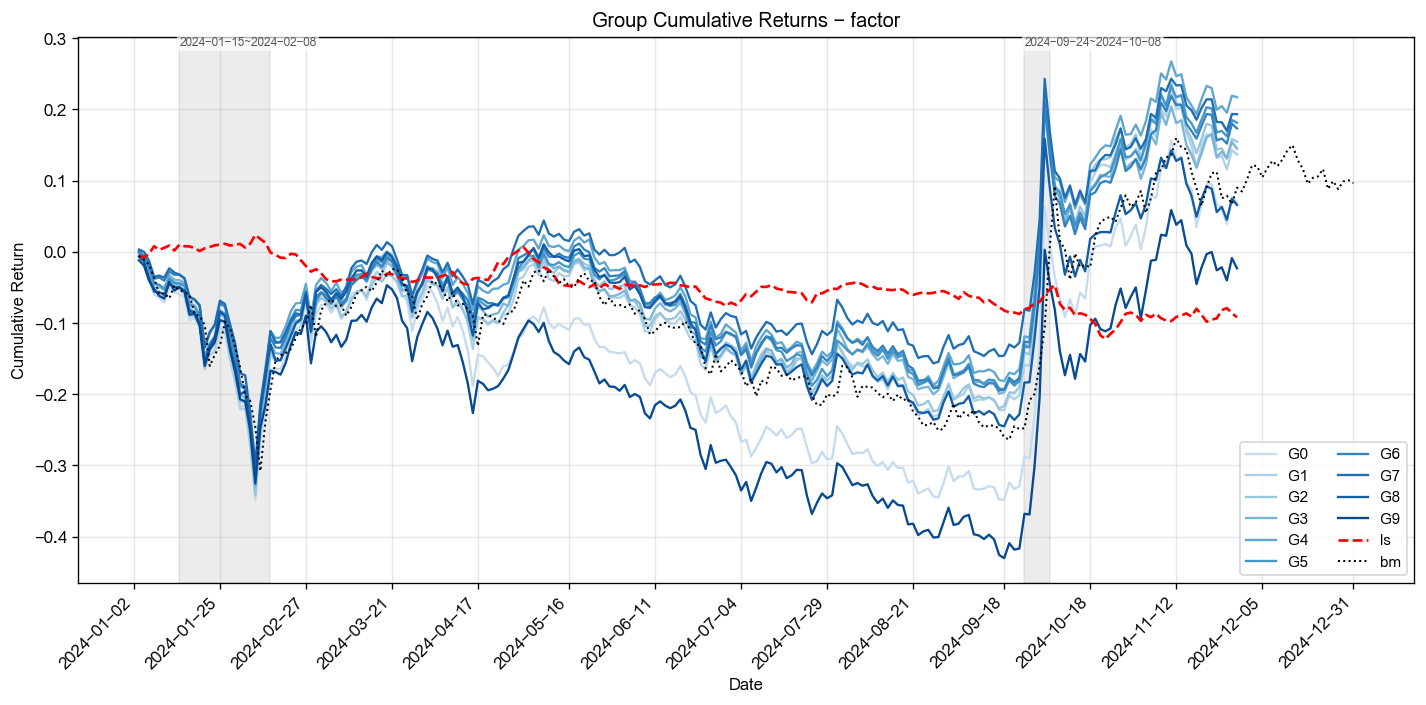
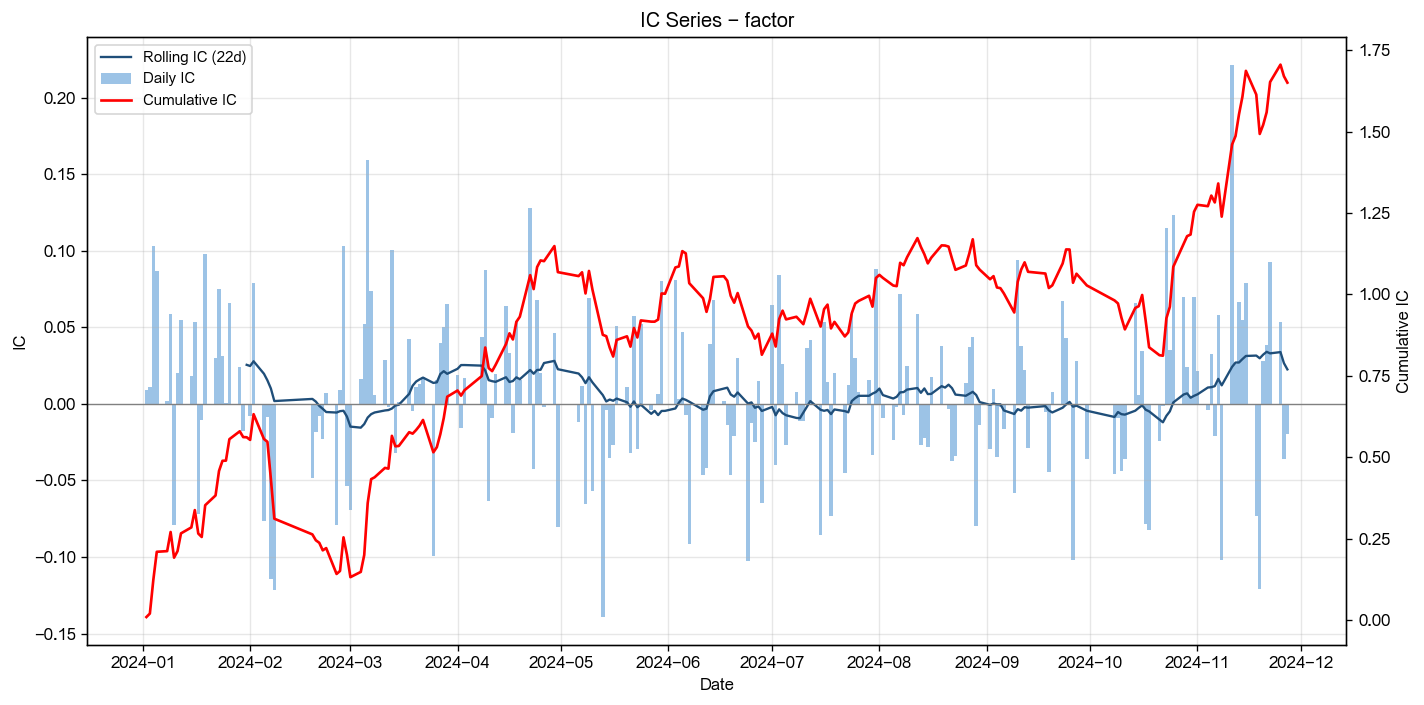
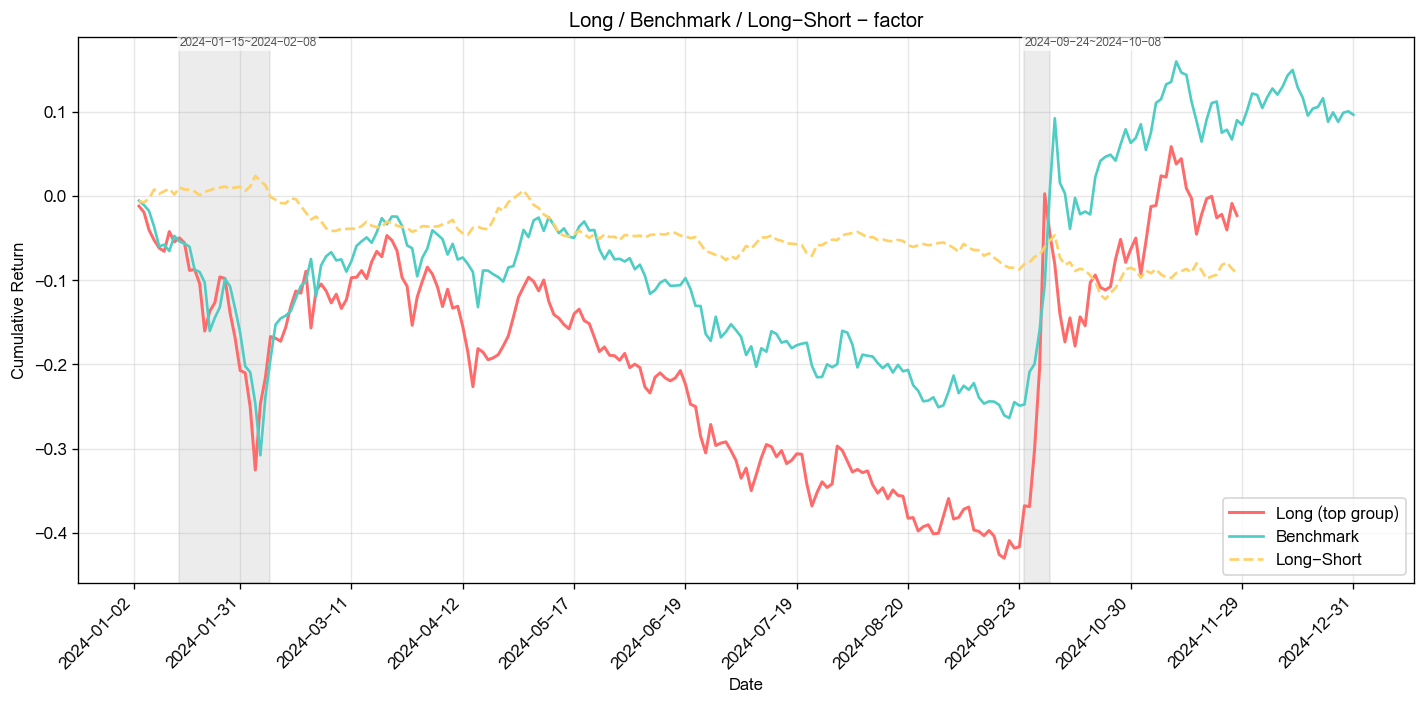
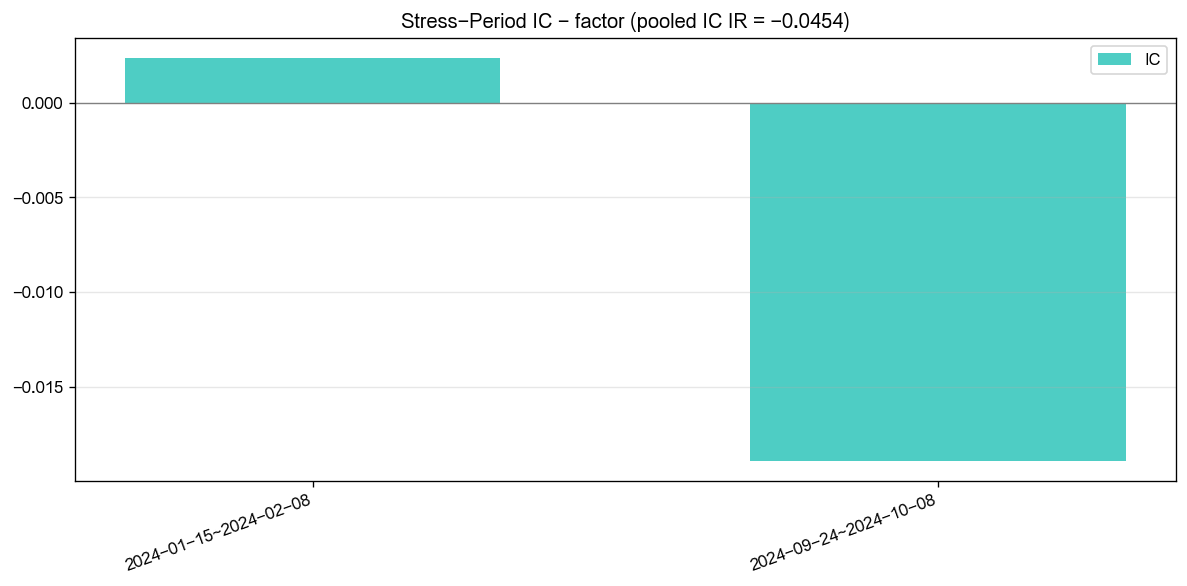
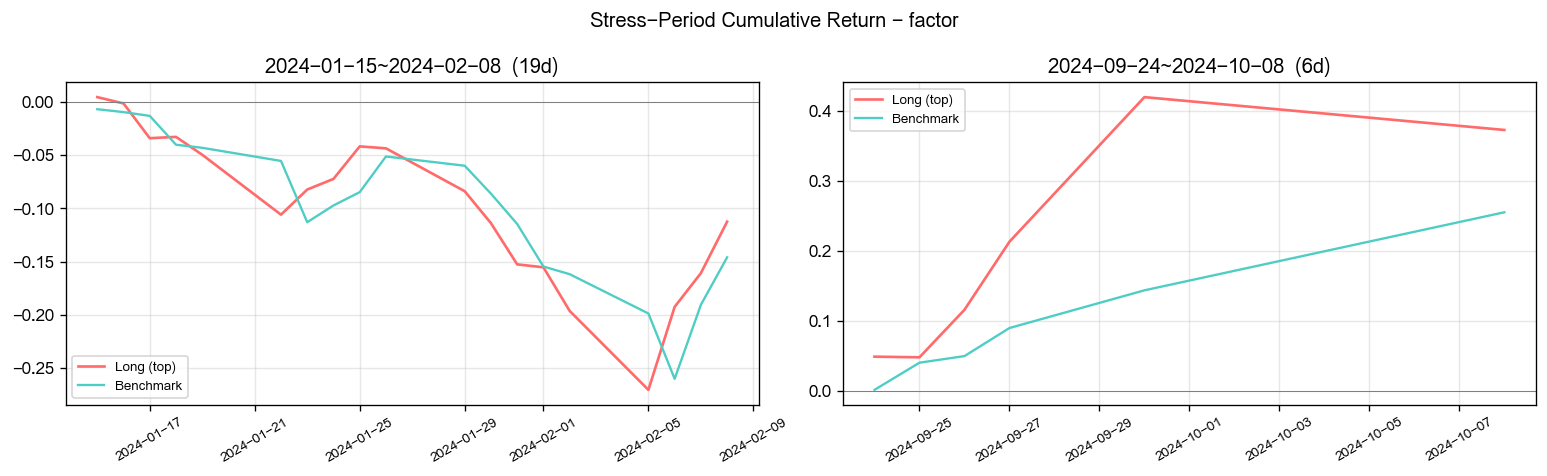

[2026-07-04 11:11:06] [info     ] ========== 因子池回归 ==========
[2026-07-04 11:11:06] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-04 11:11:07] [info     ] 获取收益率数据, 耗时: 1.5342 秒
[2026-07-04 11:11:09] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.4623 秒
[2026-07-04 11:11:09] [info     ] 统计 回归结果, 耗时: 0.1024 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9478,0.0450,0.0231,1.0000
2,amount,1.5817,0.0180,0.0114,0.9000
3,netflow_amount_rate_main,1.5715,0.0098,0.0062,1.0000
4,netflow_amount_main,1.5099,0.0250,0.0166,1.0000
5,gross_profit_rate_ttm,1.5064,0.0069,0.0046,1.0000
6,net_profit_rate_ttm,1.4444,0.0040,0.0027,0.8000
7,pb,1.4208,0.0096,0.0067,1.0000
8,bias_20,1.4062,0.0291,0.0207,0.9000
9,cci_14,1.3755,0.0341,0.0248,1.0000
10,float_market_cap,1.3149,0.0109,0.0083,0.9000

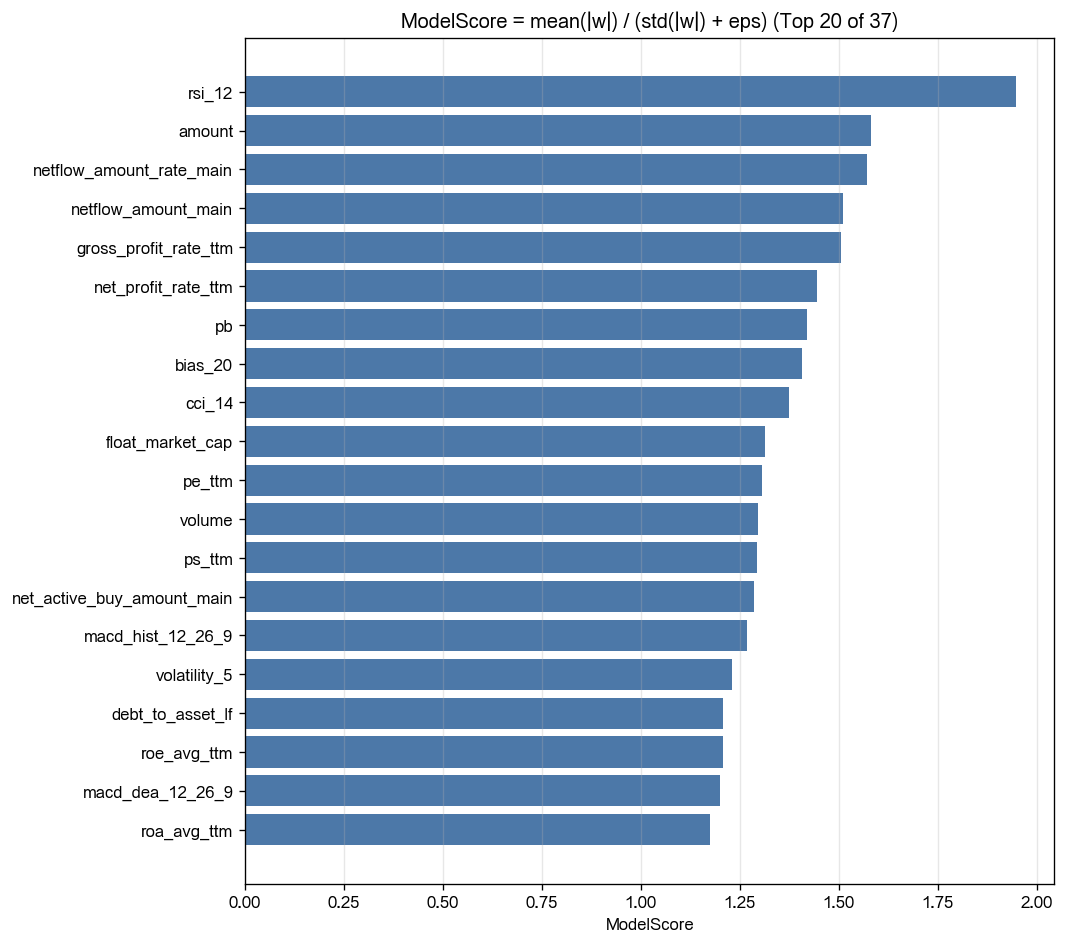
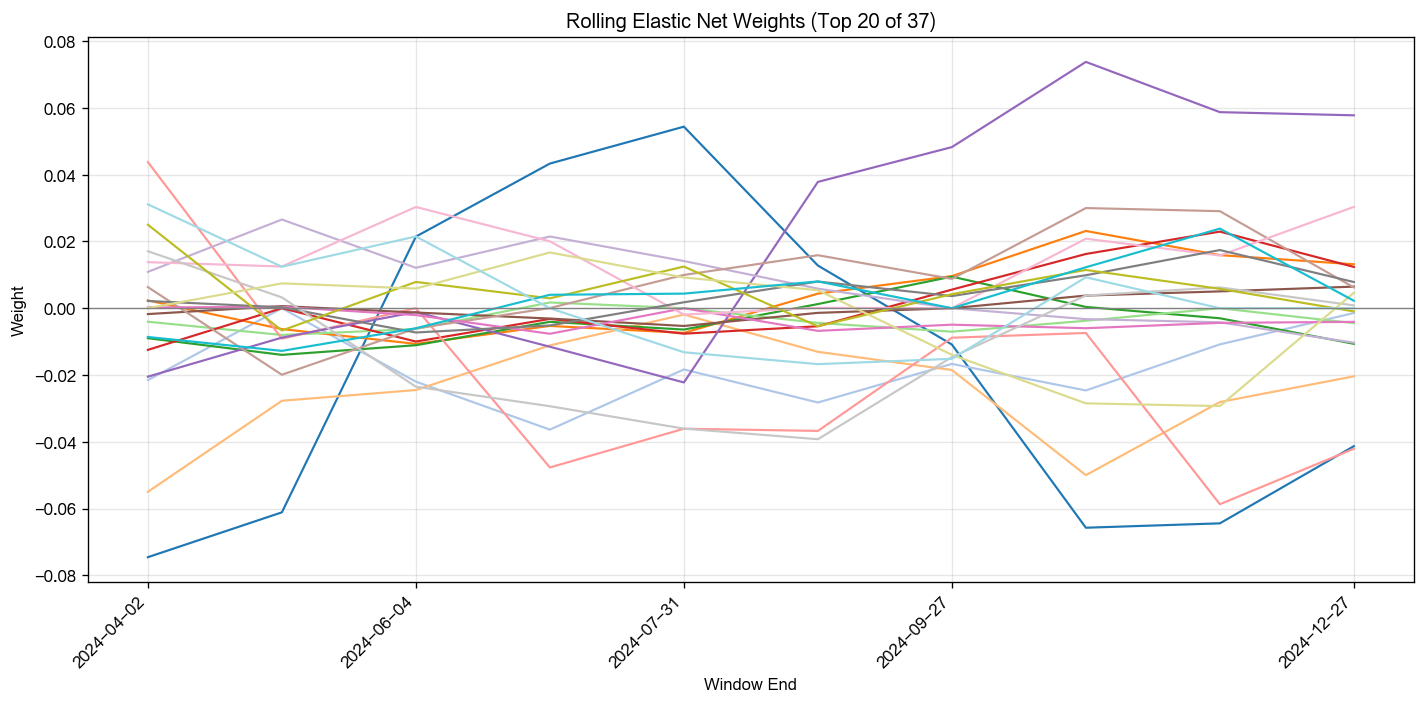
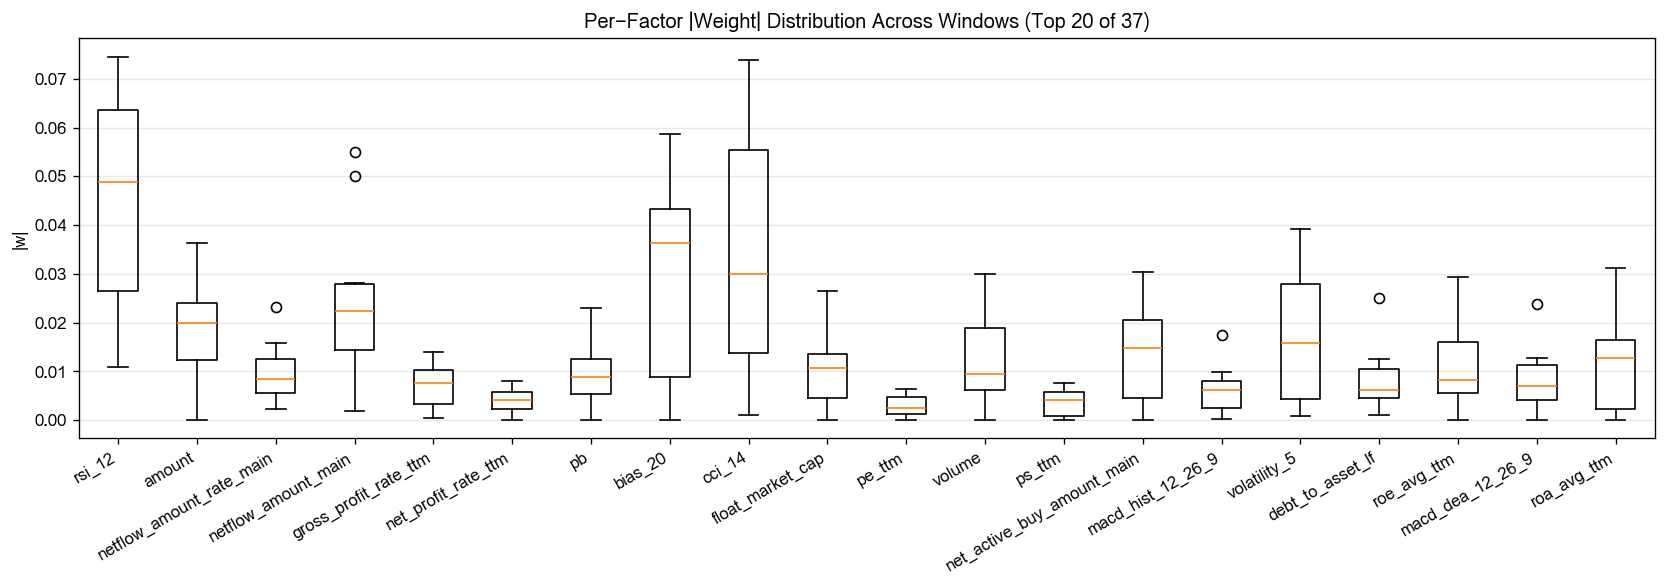
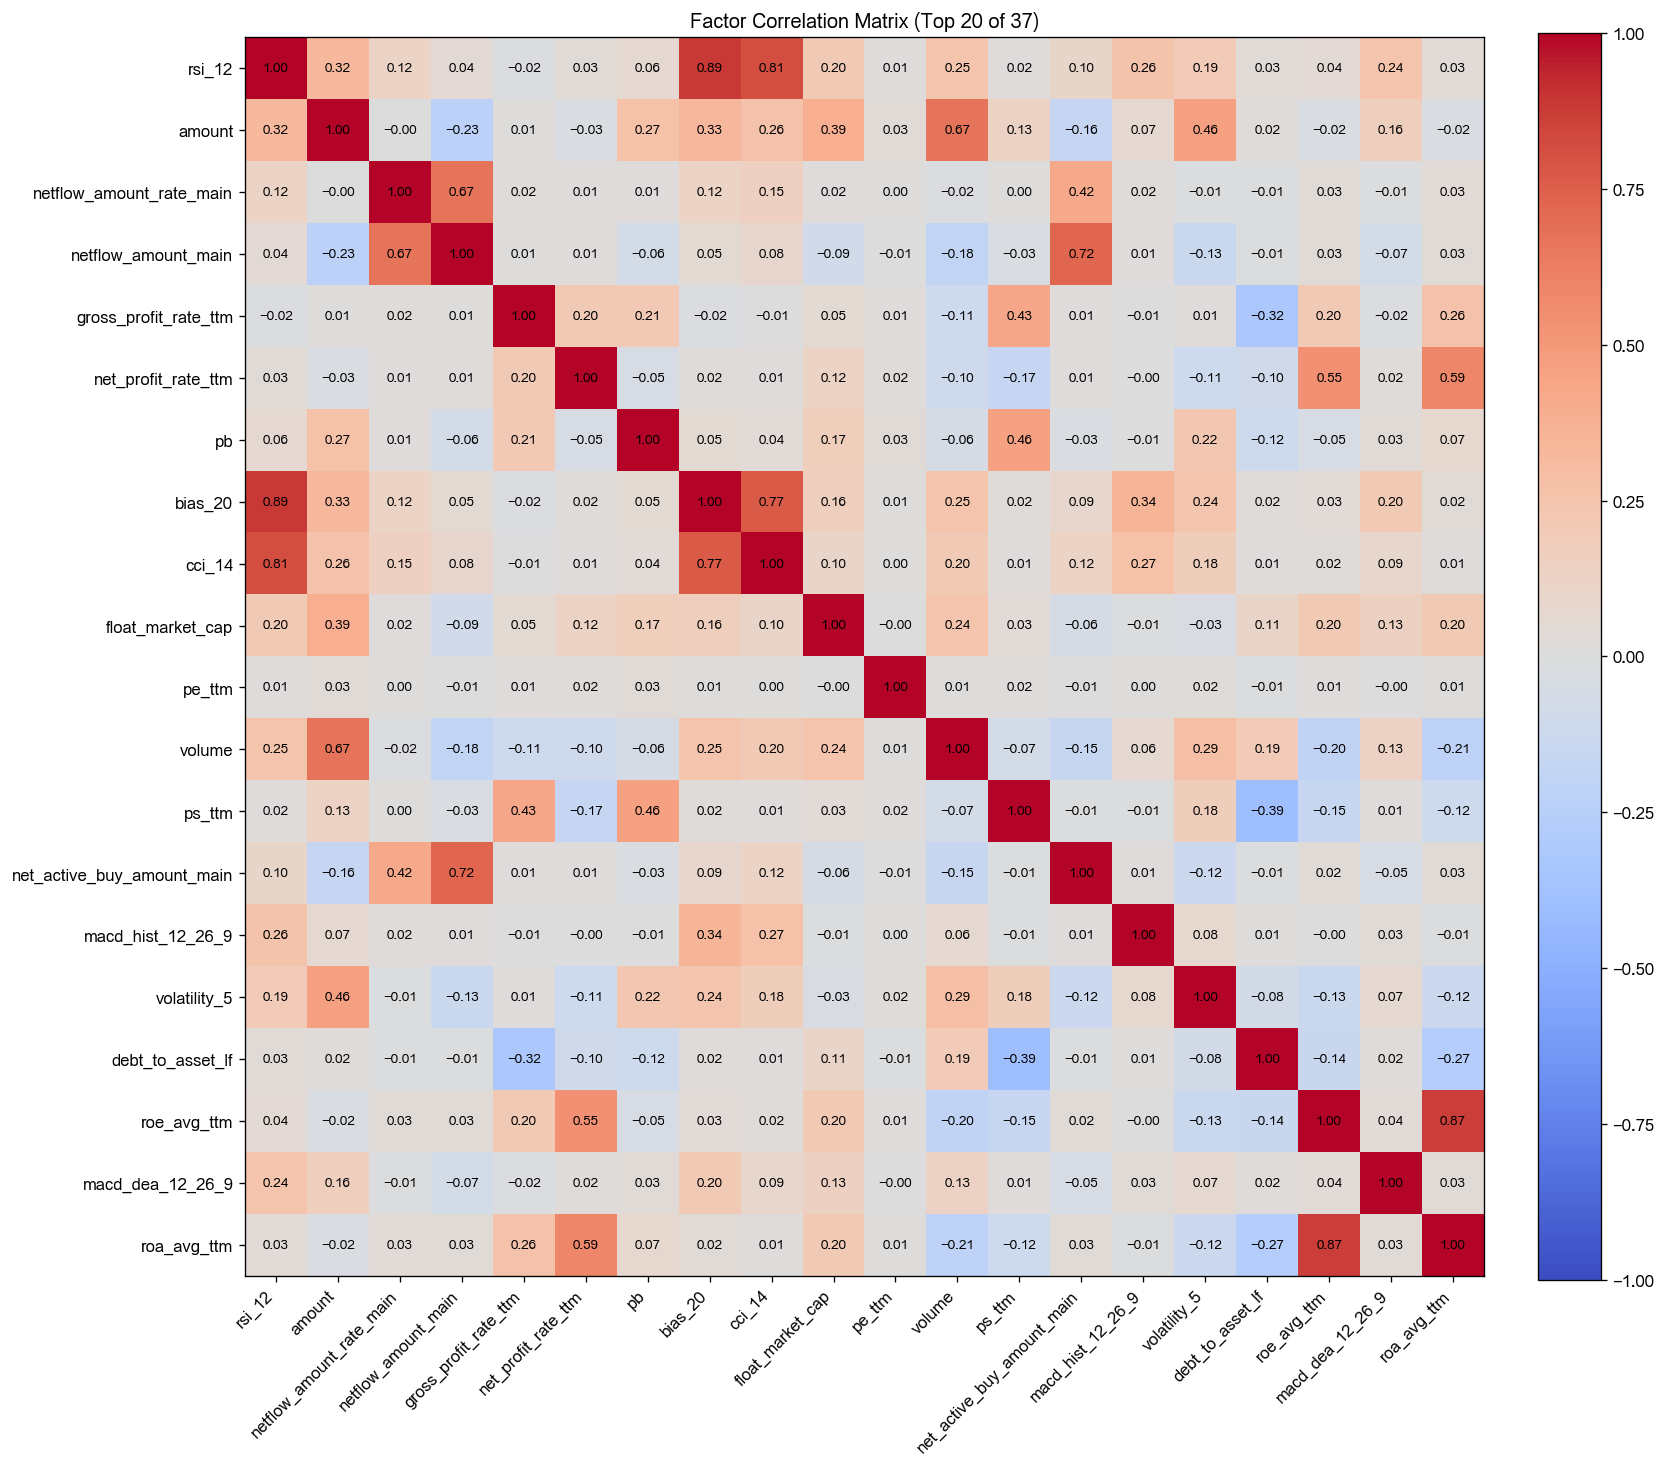

[2026-07-04 11:11:11] [warning  ] 返回的Outputs实例(size=35356285) 大于 64K, 将不会被缓存
[2026-07-04 11:11:11] [info     ] bigalpha_eval.v4 运行完成 [114.646s].


In [1]:
def main(datasources, start_date, end_date):
    """
    BigAlpha 2026 因子构建主函数：冲奖增强版

    核心思路：
        1. 使用写死训练区间训练模型，避免测试集泄漏。
        2. 分钟行情聚合到日频。
        3. 构造量价、波动、流动性、财务质量、估值代理等因子。
        4. 在训练集上计算 IC / ICIR，自动选择稳定因子。
        5. 对因子做横截面 winsorize + zscore。
        6. 使用 XGBoost 预测未来 1 日收益，预测值作为机器学习因子。
        7. 融合 ML 因子与 IC 加权线性因子，增强稳定性。
        8. 输出 ['date', 'instrument', 'factor']。

    参数:
        datasources (dict):
            {
                "bar1m": 分钟K线表,
                "financial": 财务数据表
            }

        start_date (str): 平台注入的测试集开始时间
        end_date (str):   平台注入的测试集结束时间

    返回:
        pd.DataFrame: columns = ['date', 'instrument', 'factor']
    """

    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog

    logger = structlog.get_logger()

    # ============================================================
    # 1. 固定训练区间
    # ============================================================
    # 保守版本：沿用官方示例训练区间，避免训练区间和平台测试区间发生潜在重叠。
    # 后续你可以尝试改成 2023-01-01 ~ 2023-12-31，看本地评估是否更好。
    TRAIN_START = "2023-01-01 00:00:00"
    TRAIN_END = "2023-03-31 23:59:59"

    # 因子最长回看窗口
    LOOKBACK_DAYS = 90

    price_cols = ["open", "high", "low", "close", "volume", "amount"]

    fin_cols = [
        "operating_revenue",
        "net_profit_to_parent_shareholders",
        "total_assets",
        "total_equity_to_parent_shareholders",
    ]

    RAW_FEATURE_COLS = price_cols + fin_cols

    # ============================================================
    # 2. 工具函数
    # ============================================================
    def safe_div(a, b):
        return a / (b.replace(0, np.nan) + 1e-12)

    def clean_numeric(df, cols):
        for col in cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
                df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        return df

    def cross_sectional_winsorize_zscore(df, cols):
        """
        每个交易日横截面去极值 + 标准化。
        这是冲榜非常关键的一步，否则模型容易学到量纲、规模和极值噪声。
        """
        df = df.copy()

        def _winsor_zscore(s):
            s = pd.to_numeric(s, errors="coerce")
            if s.notna().sum() < 5:
                return s * np.nan

            low = s.quantile(0.01)
            high = s.quantile(0.99)
            s = s.clip(lower=low, upper=high)

            mean = s.mean()
            std = s.std()

            if pd.isna(std) or std < 1e-12:
                return s * 0.0

            return (s - mean) / (std + 1e-12)

        for col in cols:
            if col in df.columns:
                df[col] = df.groupby("date")[col].transform(_winsor_zscore)

        df[cols] = df[cols].replace([np.inf, -np.inf], np.nan)
        return df

    def neutralize_by_columns(df, target_col, neutral_cols):
        """
        简单截面中性化：每天用 size / volatility 等变量回归 target，再取残差。
        若某天样本不足，则保留原始值。
        """
        df = df.copy()
        out = []

        for dt, g in df.groupby("date"):
            g = g.copy()
            valid_cols = [c for c in neutral_cols if c in g.columns]

            use_cols = [target_col] + valid_cols
            tmp = g[use_cols].replace([np.inf, -np.inf], np.nan).dropna()

            if len(tmp) < 30 or len(valid_cols) == 0:
                g[target_col + "_neu"] = g[target_col]
                out.append(g)
                continue

            y = tmp[target_col].values
            X = tmp[valid_cols].values
            X = np.column_stack([np.ones(len(X)), X])

            try:
                beta = np.linalg.lstsq(X, y, rcond=None)[0]
                resid = y - X.dot(beta)
                g[target_col + "_neu"] = np.nan
                g.loc[tmp.index, target_col + "_neu"] = resid
            except Exception:
                g[target_col + "_neu"] = g[target_col]

            out.append(g)

        return pd.concat(out, axis=0)

    # ============================================================
    # 3. 数据构建：行情日频 + 财务 PIT 合并
    # ============================================================
    def build_base_data(financial_table, bar1m_table, sd, ed, need_label=True):
        """
        构造日频基础数据。
        为了计算滚动因子，行情向前多取 LOOKBACK_DAYS 天。
        财务数据按公告日前向填充，避免未来函数。
        """
        t0 = time.time()
        logger.info("build_base_data 开始", start=str(sd), end=str(ed))

        sd_ts = pd.to_datetime(sd)
        ed_ts = pd.to_datetime(ed)

        price_start = sd_ts - pd.Timedelta(days=LOOKBACK_DAYS)
        fin_start = sd_ts - pd.Timedelta(days=365)

        # -----------------------------
        # 3.1 分钟行情聚合到日频
        # -----------------------------
        price_sql = f"""
        SELECT
            date_trunc('day', date)::DATE AS trading_day,
            instrument,
            ARG_MIN(open, date)           AS open,
            MAX(high)                     AS high,
            MIN(low)                      AS low,
            ARG_MAX(close, date)          AS close,
            SUM(volume)                   AS volume,
            SUM(amount)                   AS amount
        FROM {bar1m_table}
        GROUP BY trading_day, instrument
        ORDER BY trading_day, instrument
        """

        price = dai.query(
            price_sql,
            filters={"date": [price_start, ed]},
        ).df().rename(columns={"trading_day": "date"})

        price["date"] = pd.to_datetime(price["date"])
        price["instrument"] = price["instrument"].astype(str)
        price = price.sort_values(["instrument", "date"]).reset_index(drop=True)

        price = clean_numeric(price, price_cols)

        # -----------------------------
        # 3.2 标签：未来 1 日收益
        # -----------------------------
        if need_label:
            g_close = price.groupby("instrument")["close"]
            price["label"] = g_close.shift(-1) / price["close"] - 1
            price["label"] = price["label"].replace([np.inf, -np.inf], np.nan)

        # -----------------------------
        # 3.3 财务数据
        # -----------------------------
        fin_select = ", ".join(fin_cols)

        fin_sql = f"""
        SELECT
            date,
            instrument,
            {fin_select}
        FROM {financial_table}
        WHERE category = 'lf'
          AND shift = 0
        ORDER BY instrument, date
        """

        fin = dai.query(
            fin_sql,
            filters={"date": [fin_start, ed]},
        ).df()

        fin["date"] = pd.to_datetime(fin["date"])
        fin["instrument"] = fin["instrument"].astype(str)
        fin = clean_numeric(fin, fin_cols)

        # -----------------------------
        # 3.4 PIT 合并财务数据
        # 用 merge_asof 语义：每个交易日只能看到此前已经公告的数据
        # -----------------------------
        if len(fin) > 0:
            merged_list = []

            for inst, p in price.groupby("instrument", sort=False):
                f = fin[fin["instrument"] == inst].sort_values("date")

                p = p.sort_values("date")

                if len(f) == 0:
                    for col in fin_cols:
                        p[col] = np.nan
                    merged_list.append(p)
                    continue

                p2 = pd.merge_asof(
                    p,
                    f[["date", "instrument"] + fin_cols],
                    on="date",
                    by="instrument",
                    direction="backward",
                )
                merged_list.append(p2)

            df = pd.concat(merged_list, axis=0, ignore_index=True)
        else:
            df = price.copy()
            for col in fin_cols:
                df[col] = np.nan

        # 只保留目标输出区间。前面的 buffer 只用于 rolling 特征。
        df = df[(df["date"] >= sd_ts) & (df["date"] <= ed_ts)]
        df = df.sort_values(["instrument", "date"]).reset_index(drop=True)

        logger.info(
            "build_base_data 结束",
            rows=len(df),
            elapsed=round(time.time() - t0, 2),
        )

        return df

    # ============================================================
    # 4. 因子池构建
    # ============================================================
    def build_factor_pool(df):
        df = df.copy()
        df = df.sort_values(["instrument", "date"]).reset_index(drop=True)

        df = clean_numeric(df, RAW_FEATURE_COLS)

        g = df.groupby("instrument", group_keys=False)

        # -----------------------------
        # 4.1 基础收益
        # -----------------------------
        df["ret_1"] = g["close"].pct_change(1)
        df["ret_3"] = g["close"].pct_change(3)
        df["ret_5"] = g["close"].pct_change(5)
        df["ret_10"] = g["close"].pct_change(10)
        df["ret_20"] = g["close"].pct_change(20)

        # -----------------------------
        # 4.2 动量 / 反转
        # -----------------------------
        df["mom_5"] = df["ret_5"]
        df["mom_10"] = df["ret_10"]
        df["mom_20"] = df["ret_20"]

        df["rev_1"] = -df["ret_1"]
        df["rev_3"] = -df["ret_3"]
        df["rev_5"] = -df["ret_5"]

        # -----------------------------
        # 4.3 K线结构
        # -----------------------------
        df["intraday_ret"] = safe_div(df["close"], df["open"]) - 1
        df["high_low_range"] = safe_div(df["high"] - df["low"], df["close"])
        df["close_to_high"] = safe_div(df["close"], df["high"]) - 1
        df["close_to_low"] = safe_div(df["close"], df["low"]) - 1

        # -----------------------------
        # 4.4 波动率
        # -----------------------------
        df["volatility_5"] = g["ret_1"].transform(lambda x: x.rolling(5, min_periods=3).std())
        df["volatility_10"] = g["ret_1"].transform(lambda x: x.rolling(10, min_periods=5).std())
        df["volatility_20"] = g["ret_1"].transform(lambda x: x.rolling(20, min_periods=10).std())

        df["downside_vol_20"] = g["ret_1"].transform(
            lambda x: x.where(x < 0).rolling(20, min_periods=8).std()
        )

        # -----------------------------
        # 4.5 均线偏离
        # -----------------------------
        ma_5 = g["close"].transform(lambda x: x.rolling(5, min_periods=3).mean())
        ma_10 = g["close"].transform(lambda x: x.rolling(10, min_periods=5).mean())
        ma_20 = g["close"].transform(lambda x: x.rolling(20, min_periods=10).mean())

        df["ma_gap_5"] = safe_div(df["close"], ma_5) - 1
        df["ma_gap_10"] = safe_div(df["close"], ma_10) - 1
        df["ma_gap_20"] = safe_div(df["close"], ma_20) - 1

        # -----------------------------
        # 4.6 成交量 / 成交额
        # -----------------------------
        vol_ma_5 = g["volume"].transform(lambda x: x.rolling(5, min_periods=3).mean())
        vol_ma_20 = g["volume"].transform(lambda x: x.rolling(20, min_periods=10).mean())
        amt_ma_5 = g["amount"].transform(lambda x: x.rolling(5, min_periods=3).mean())
        amt_ma_20 = g["amount"].transform(lambda x: x.rolling(20, min_periods=10).mean())

        df["volume_ma5_ratio"] = safe_div(df["volume"], vol_ma_5)
        df["volume_ma20_ratio"] = safe_div(df["volume"], vol_ma_20)
        df["amount_ma5_ratio"] = safe_div(df["amount"], amt_ma_5)
        df["amount_ma20_ratio"] = safe_div(df["amount"], amt_ma_20)

        df["volume_chg_1"] = g["volume"].pct_change(1)
        df["volume_chg_5"] = g["volume"].pct_change(5)
        df["amount_chg_1"] = g["amount"].pct_change(1)
        df["amount_chg_5"] = g["amount"].pct_change(5)

        # -----------------------------
        # 4.7 量价结合
        # -----------------------------
        df["ret_volume_5"] = df["ret_5"] * df["volume_ma20_ratio"]
        df["ret_amount_5"] = df["ret_5"] * df["amount_ma20_ratio"]
        df["ret_volume_20"] = df["ret_20"] * df["volume_ma20_ratio"]
        df["ret_amount_20"] = df["ret_20"] * df["amount_ma20_ratio"]

        # 非流动性冲击：越大代表同样成交额下价格冲击越大
        df["illiq_20"] = g.apply(
            lambda x: safe_div(x["ret_1"].abs(), x["amount"]).rolling(20, min_periods=10).mean()
        ).reset_index(level=0, drop=True)

        # -----------------------------
        # 4.8 财务质量 / 规模代理
        # -----------------------------
        df["log_assets"] = np.log(df["total_assets"].clip(lower=1))
        df["log_revenue"] = np.log(df["operating_revenue"].abs().clip(lower=1))

        df["roe"] = safe_div(
            df["net_profit_to_parent_shareholders"],
            df["total_equity_to_parent_shareholders"],
        )

        df["roa"] = safe_div(
            df["net_profit_to_parent_shareholders"],
            df["total_assets"],
        )

        df["profit_margin"] = safe_div(
            df["net_profit_to_parent_shareholders"],
            df["operating_revenue"],
        )

        df["equity_ratio"] = safe_div(
            df["total_equity_to_parent_shareholders"],
            df["total_assets"],
        )

        # -----------------------------
        # 4.9 清理
        # -----------------------------
        all_new_cols = [
            c for c in df.columns
            if c not in ["date", "instrument", "label"]
        ]

        df = clean_numeric(df, all_new_cols)
        df[all_new_cols] = df[all_new_cols].replace([np.inf, -np.inf], np.nan)

        return df

    # ============================================================
    # 5. IC 计算与因子筛选
    # ============================================================
    def calc_factor_ic_stats(df, factor_cols):
        records = []

        for col in factor_cols:
            ic_list = []

            for dt, g in df.groupby("date"):
                sub = g[[col, "label"]].replace([np.inf, -np.inf], np.nan).dropna()

                if len(sub) < 30:
                    continue

                if sub[col].nunique() < 5 or sub["label"].nunique() < 5:
                    continue

                ic = sub[col].corr(sub["label"], method="spearman")

                if pd.notna(ic):
                    ic_list.append(ic)

            if len(ic_list) == 0:
                records.append({
                    "factor": col,
                    "ic_mean": 0.0,
                    "ic_std": np.nan,
                    "ic_ir": 0.0,
                    "ic_abs_score": 0.0,
                    "direction": 1.0,
                })
                continue

            ic_s = pd.Series(ic_list)
            ic_mean = ic_s.mean()
            ic_std = ic_s.std()
            ic_ir = ic_mean / (ic_std + 1e-12)

            # 选择标准：兼顾 IC 均值和稳定性
            score = abs(ic_mean) * (abs(ic_ir) + 0.1)

            records.append({
                "factor": col,
                "ic_mean": float(ic_mean),
                "ic_std": float(ic_std) if pd.notna(ic_std) else np.nan,
                "ic_ir": float(ic_ir) if pd.notna(ic_ir) else 0.0,
                "ic_abs_score": float(score),
                "direction": 1.0 if ic_mean >= 0 else -1.0,
            })

        stat = pd.DataFrame(records)
        stat = stat.sort_values("ic_abs_score", ascending=False).reset_index(drop=True)
        return stat

    def select_top_factors(ic_stat, max_features=18, min_features=8):
        """
        选取稳定因子。
        如果有效因子太少，则退化为前 min_features 个，防止模型空特征。
        """
        stat = ic_stat.copy()

        stat = stat.replace([np.inf, -np.inf], np.nan)
        stat = stat.dropna(subset=["ic_abs_score"])

        # 剔除几乎无效的因子，但不要太激进
        valid = stat[stat["ic_abs_score"] > 0]

        if len(valid) >= min_features:
            selected = valid.head(max_features)
        else:
            selected = stat.head(max(min_features, min(len(stat), max_features)))

        return selected["factor"].tolist(), selected

    # ============================================================
    # 6. 训练模型
    # ============================================================
    def train_xgb_model(train_df, feature_cols):
        X = train_df[feature_cols].copy()
        y = train_df["label"].copy()

        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        y = y.replace([np.inf, -np.inf], np.nan)

        valid = y.notna()
        X = X.loc[valid]
        y = y.loc[valid]

        # 标签做一点截尾，防止极端涨跌停 / 停牌异常污染模型
        y_low = y.quantile(0.01)
        y_high = y.quantile(0.99)
        y = y.clip(lower=y_low, upper=y_high)

        model = xgb.XGBRegressor(
            n_estimators=80,
            max_depth=3,
            learning_rate=0.035,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=20,
            reg_lambda=5.0,
            reg_alpha=0.5,
            objective="reg:squarederror",
            tree_method="hist",
            n_jobs=-1,
            random_state=42,
        )

        model.fit(X, y)
        return model

    # ============================================================
    # 7. 线性 IC 加权因子
    # ============================================================
    def add_linear_ic_factor(df, selected_stat):
        df = df.copy()

        weights = {}
        for _, row in selected_stat.iterrows():
            f = row["factor"]
            # 用方向修正负 IC 因子
            w = row["direction"] * max(abs(row["ic_mean"]), 1e-6)
            weights[f] = w

        total_abs_w = sum(abs(v) for v in weights.values()) + 1e-12

        lin = 0.0
        for f, w in weights.items():
            if f in df.columns:
                lin = lin + (w / total_abs_w) * df[f].fillna(0.0)

        df["linear_ic_factor"] = lin
        return df

    # ============================================================
    # 8. 开始训练
    # ============================================================
    t_all = time.time()

    logger.info("开始构建训练集", train_start=TRAIN_START, train_end=TRAIN_END)

    # 训练集：仍然使用官方固定表名
    train_df = build_base_data(
        financial_table="bigalpha_2026_financial",
        bar1m_table="bigalpha_2026_stock_bar1m",
        sd=TRAIN_START,
        ed=TRAIN_END,
        need_label=True,
    )

    train_df = build_factor_pool(train_df)

    # 原始特征 + 工程因子候选
    exclude_cols = {"date", "instrument", "label"}
    candidate_factor_cols = [
        c for c in train_df.columns
        if c not in exclude_cols
    ]

    # 保留数值列
    candidate_factor_cols = [
        c for c in candidate_factor_cols
        if pd.api.types.is_numeric_dtype(train_df[c])
    ]

    train_df = clean_numeric(train_df, candidate_factor_cols + ["label"])

    # 训练集中 label 不可为空
    train_df["label"] = train_df["label"].replace([np.inf, -np.inf], np.nan)
    train_df = train_df.dropna(subset=["label"]).reset_index(drop=True)

    # 先做截面标准化，再计算 IC
    train_df = cross_sectional_winsorize_zscore(train_df, candidate_factor_cols)

    logger.info("开始计算训练集 IC", candidate_factors=len(candidate_factor_cols))
    ic_stat = calc_factor_ic_stats(train_df, candidate_factor_cols)

    selected_features, selected_stat = select_top_factors(
        ic_stat,
        max_features=18,
        min_features=8,
    )

    logger.info(
        "因子筛选完成",
        selected_features=selected_features,
    )

    # 方向修正：负 IC 因子乘 -1，让模型输入更一致
    direction_map = {
        row["factor"]: row["direction"]
        for _, row in selected_stat.iterrows()
    }

    for f in selected_features:
        train_df[f] = train_df[f] * direction_map.get(f, 1.0)

    # 可选中性化：对机器学习前的部分风格偏差做削弱
    neutral_cols = []
    for c in ["log_assets", "volatility_20", "amount_ma20_ratio"]:
        if c in selected_features:
            neutral_cols.append(c)

    # 为了稳定，先不对每个输入因子都中性化，只中性化最终 linear factor 和 ml factor
    train_df = add_linear_ic_factor(train_df, selected_stat)

    logger.info("开始训练 XGBoost", samples=len(train_df), features=len(selected_features))
    t_fit = time.time()

    model = train_xgb_model(train_df, selected_features)

    logger.info("模型训练完成", elapsed=round(time.time() - t_fit, 2))

    # ============================================================
    # 9. 测试集预测
    # ============================================================
    logger.info("开始构建测试集", start=start_date, end=end_date)

    bar1m_table = datasources["bar1m"]
    financial_table = datasources["financial"]

    test_df = build_base_data(
        financial_table=financial_table,
        bar1m_table=bar1m_table,
        sd=start_date,
        ed=end_date,
        need_label=False,
    )

    test_df = build_factor_pool(test_df)

    # 测试集只使用训练时选出来的因子
    for f in selected_features:
        if f not in test_df.columns:
            test_df[f] = np.nan

    test_df = clean_numeric(test_df, selected_features)

    # 截面标准化
    test_df = cross_sectional_winsorize_zscore(test_df, selected_features)

    # 方向修正
    for f in selected_features:
        test_df[f] = test_df[f] * direction_map.get(f, 1.0)

    # 线性 IC 因子
    test_df = add_linear_ic_factor(test_df, selected_stat)

    X_test = test_df[selected_features].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    test_df["ml_factor"] = model.predict(X_test)

    # 对 ML 输出再做截面标准化
    test_df = cross_sectional_winsorize_zscore(
        test_df,
        ["ml_factor", "linear_ic_factor"],
    )

    # 简单中性化：减少 size / volatility / liquidity 暴露
    # 注意：中性化不是越多越好，过度中性化会损失 alpha。
    neutral_base_cols = [
        c for c in ["log_assets", "volatility_20", "amount_ma20_ratio"]
        if c in test_df.columns
    ]

    if len(neutral_base_cols) > 0:
        # neutral_base_cols 也需要标准化，否则回归量纲会不稳
        test_df = cross_sectional_winsorize_zscore(test_df, neutral_base_cols)

        test_df = neutralize_by_columns(
            test_df,
            target_col="ml_factor",
            neutral_cols=neutral_base_cols,
        )

        test_df = neutralize_by_columns(
            test_df,
            target_col="linear_ic_factor",
            neutral_cols=neutral_base_cols,
        )

        ml_col = "ml_factor_neu"
        lin_col = "linear_ic_factor_neu"
    else:
        ml_col = "ml_factor"
        lin_col = "linear_ic_factor"

    test_df = cross_sectional_winsorize_zscore(test_df, [ml_col, lin_col])

    # ============================================================
    # 10. 最终融合
    # ============================================================
    # 机器学习更强，但线性 IC 因子更稳。
    # 0.70 / 0.30 是偏冲榜的折中。
    test_df["factor"] = (
        0.70 * test_df[ml_col].fillna(0.0)
        + 0.30 * test_df[lin_col].fillna(0.0)
    )

    test_df = cross_sectional_winsorize_zscore(test_df, ["factor"])

    # ============================================================
    # 11. 对齐中证 1000 成分股
    # ============================================================
    stk_pool = dai.query(
        """
        SELECT date, instrument
        FROM bigalpha_2026_instruments
        """,
        filters={"date": [start_date, end_date]},
    ).df()

    stk_pool["date"] = pd.to_datetime(stk_pool["date"])
    stk_pool["instrument"] = stk_pool["instrument"].astype(str)

    result = pd.merge(
        test_df[["date", "instrument", "factor"]],
        stk_pool,
        how="inner",
        on=["date", "instrument"],
    )

    result["factor"] = pd.to_numeric(result["factor"], errors="coerce")
    result["factor"] = result["factor"].replace([np.inf, -np.inf], np.nan)

    result = result.dropna(subset=["factor"])
    result = result.sort_values(["date", "instrument"]).reset_index(drop=True)

    result = result[["date", "instrument", "factor"]]

    logger.info(
        "因子构建完成",
        rows=len(result),
        selected_features=selected_features,
        total_elapsed=round(time.time() - t_all, 2),
    )

    return result


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m",
        "financial": "bigalpha_2026_financial",
    }

    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        """
        SELECT *
        FROM bigalpha_2026_factorlib
        """,
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )